In [1]:
import pandas as pd
import numpy as np
import spacy

import matplotlib.pyplot as plt

real_df = pd.read_csv("emails_preprocessed.csv")

real_df.head()

/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.13) or chardet (7.6.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(
/tmp/ipykernel_730059/1605974510.py:7: DtypeWarning: Columns (14: X-bcc, 18: Time, 19: Attendees) have mixed types. Specify dtype option on import or set low_memory=False.
  real_df = pd.read_csv("emails_preprocessed.csv")


,file,Message-ID,Date,From,To,Cc,Bcc,Subject,Mime-Version,Content-Type,...,body,signature,attachment_count,attachment_names,parse_error,embed_text,ctfidf_text,full_message,subj_norm,thread_id
0,allen-p/all_documents/157.,<12929996.1075855668941.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,muller@thedoghousemail.com,NaN,NaN,Re: (No Subject),1.0,"text/plain; charset=""us-ascii""",...,How is your racing going? What category are y...,NaN,0,[],NaN,Re: (No Subject) How is your racing going? Wha...,re no subject how is your racing going what ca...,Re: (No Subject) How is your racing going? Wha...,(no subject),0
1,allen-p/all_documents/188.,<29770699.1075855669609.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,"stephen.harrington@enron.com, mary@enron.com",NaN,NaN,NaN,1.0,"text/plain; charset=""us-ascii""",...,EOL report for TV in conference on 33\n\nCash\...,NaN,0,[],NaN,EOL report for TV in conference on 33\n\nCash\...,eol report for tv in conference on 33 cash heh...,EOL report for TV in conference on 33\n\nCash\...,NaN,1
2,allen-p/all_documents/202.,<13537630.1075855669909.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,jsmith@austintx.com,NaN,NaN,Re: MISSION SOUTH,1.0,"text/plain; charset=""us-ascii""",...,"Jeff,\n\n I want to bid $2.8 for sagewood with...",NaN,0,[],NaN,"Re: MISSION SOUTH Jeff,\n\n I want to bid $2.8...",re mission south jeff i want to bid 28 for sag...,"Re: MISSION SOUTH Jeff,\n\n I want to bid $2.8...",mission south,2
3,allen-p/all_documents/203.,<27903020.1075855669931.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,"john.lavorato@enron.com, beth.perlman@enron.co...",NaN,NaN,systems wish list,1.0,"text/plain; charset=""us-ascii""",...,attached is the systems wish list for the gas ...,NaN,0,[],NaN,systems wish list attached is the systems wish...,systems wish list attached is the systems wish...,systems wish list attached is the systems wish...,systems wish list,3
4,allen-p/all_documents/319.,<17449361.1075855672476.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,maryrichards7@hotmail.com,NaN,NaN,Re:,1.0,"text/plain; charset=""us-ascii""",...,"Mary,\n\n It is OK to buy a carpet shampooer.\...",NaN,0,[],NaN,"Re: Mary,\n\n It is OK to buy a carpet shampoo...",re mary it is ok to buy a carpet shampooer abo...,"Re: Mary,\n\n It is OK to buy a carpet shampoo...",NaN,4


In [2]:
real_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 228261 entries, 0 to 228260
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   file                       228261 non-null  str    
 1   Message-ID                 228261 non-null  str    
 2   Date                       228261 non-null  str    
 3   From                       228261 non-null  str    
 4   To                         220364 non-null  str    
 5   Cc                         55652 non-null   str    
 6   Bcc                        55652 non-null   str    
 7   Subject                    220697 non-null  str    
 8   Mime-Version               228233 non-null  float64
 9   Content-Type               228233 non-null  str    
 10  Content-Transfer-Encoding  228233 non-null  str    
 11  X-From                     228233 non-null  str    
 12  X-To                       223488 non-null  str    
 13  X-cc                       56198 non-nul

In [3]:
real_df.columns

Index(['file', 'Message-ID', 'Date', 'From', 'To', 'Cc', 'Bcc', 'Subject',
       'Mime-Version', 'Content-Type', 'Content-Transfer-Encoding', 'X-From',
       'X-To', 'X-cc', 'X-bcc', 'X-Folder', 'X-Origin', 'X-FileName', 'Time',
       'Attendees', 'Re', 'date_parsed', 'body_raw', 'body', 'signature',
       'attachment_count', 'attachment_names', 'parse_error', 'embed_text',
       'ctfidf_text', 'full_message', 'subj_norm', 'thread_id'],
      dtype='str')

## Post-processing - group threads

In [4]:
# join full_message from threads together in descending order of date received

def _join_text(values: pd.Series) -> str:
    texts = values.dropna().astype(str)
    return " ".join(texts)

ordered = real_df.assign(
    date_parsed=pd.to_datetime(real_df["Date"], utc=True, errors="coerce")
).sort_values("date_parsed", ascending=False, kind="mergesort")

df = (
    ordered.groupby("thread_id", sort=False)
    .agg(
        date_received=("Date", "max"),
        subject=("Subject", "first"),
        body=("full_message", _join_text),
        ctfidf_text=("ctfidf_text", _join_text),
        msg_count=("thread_id", "count"),
    )
    .reset_index()
)
df.head()

,thread_id,date_received,subject,body,ctfidf_text,msg_count
0,228309,"Mon, 04 Jan 2044 14:48:58 -0800",trades,"trades Howdy, \nbom went out 35 at 35.5 \nFeb ...",trades howdy bom went out 35 at 355 feb traded...,2
1,228308,"Sat, 02 Jan 2044 15:46:00 -0800",trades jan 2002,trades jan 2002 feb dec trades 37.5 \nfeb dec ...,trades jan 2002 feb dec trades 375 feb dec ll ...,1
2,228307,"Mon, 28 Dec 2043 11:34:12 -0800",marks.xls,marks.xls Happy New Year !,marksxls happy new year,1
3,228306,"Sun, 26 May 2024 03:49:57 -0700",(None),(None) <html>\n<head>\n<title>Untitled Documen...,none html head titleuntitled documenttitle met...,1
4,228305,"Tue, 29 Dec 2020 12:53:46 -0800",Jennifer Lopez - Nudity,Jennifer Lopez - Nudity <html>\n<head>\n<title...,jennifer lopez nudity html head titlegt free l...,1


In [5]:
# fix the html tag leaks for now
df["body"] = df["body"].str.replace(r"<[^>]+>", "", regex=True)
df["ctfidf_text"] = df["ctfidf_text"].str.replace(r"\b(?:html|head|body|title|meta|div|span|table|font|br|href|src)\b", "", regex=True)

In [6]:
df.head()

,thread_id,date_received,subject,body,ctfidf_text,msg_count
0,228309,"Mon, 04 Jan 2044 14:48:58 -0800",trades,"trades Howdy, \nbom went out 35 at 35.5 \nFeb ...",trades howdy bom went out 35 at 355 feb traded...,2
1,228308,"Sat, 02 Jan 2044 15:46:00 -0800",trades jan 2002,trades jan 2002 feb dec trades 37.5 \nfeb dec ...,trades jan 2002 feb dec trades 375 feb dec ll ...,1
2,228307,"Mon, 28 Dec 2043 11:34:12 -0800",marks.xls,marks.xls Happy New Year !,marksxls happy new year,1
3,228306,"Sun, 26 May 2024 03:49:57 -0700",(None),(None) \n\nUntitled Document\n\n\n\n\nEducate ...,none titleuntitled documenttitle httpequivc...,1
4,228305,"Tue, 29 Dec 2020 12:53:46 -0800",Jennifer Lopez - Nudity,Jennifer Lopez - Nudity \n\n::::&gt; FREE LIFE...,jennifer lopez nudity titlegt free lifetime ...,1


## NLP Analysis

In [7]:
import spacy

spacy.cli.download("en_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Using Python 3.13.15 environment at: /home/marco/development/email-cls-with-clustering/.venv
Checked 1 package in 3ms


In [8]:
# import multiprocessing

# nlp = spacy.load("en_core_web_sm", disable=["parser"])

# EMAIL_STOP = {
#     "enron", "ect", "hou", "cc", "subject", "re", "fwd", "date", "from", "to", "sent", "received", "message-id", "mime-version", "content-type", "content-transfer-encoding", "x-from", "x-to", "x-cc", "x-bcc", "x-date", "x-message-id", "x-mime-version", "x-content-type", "x-content-transfer-encoding", "let", "know", "would", "could", "get", "also", "thank", "email", "send", "question", "information", 
# }
# STOP = list(EMAIL_STOP) + list(nlp.Defaults.stop_words)

# def to_tokens(doc):
#     return [t.lemma_.lower() for t in doc
#             if t.is_alpha and len(t) > 2 and t.lemma_.lower() not in STOP
#             and t.pos_ in {"NOUN", "PROPN", "ADJ", "VERB"}]

# texts = df["ctfidf_text"].tolist()
# df["tokens"] = [to_tokens(d) for d in nlp.pipe(texts, batch_size = 500, n_process = multiprocessing.cpu_count()-8)]

In [9]:
# df.to_csv("emails_preprocessed_tokenized.csv", index=False)
df = pd.read_csv("emails_preprocessed_tokenized.csv")

In [14]:
from collections import Counter
dfreq = Counter((w for toks in df.tokens for w in set(toks)))

print([(w, c) for w, c in dfreq.most_common(100)])

[('thank', 31943), ('need', 28392), ('time', 26135), ('email', 25056), ('new', 23858), ('send', 23277), ('work', 21670), ('question', 19935), ('want', 19913), ('good', 19417), ('information', 18801), ('day', 18740), ('think', 18714), ('change', 18708), ('look', 18424), ('week', 18371), ('attach', 18359), ('use', 17690), ('receive', 17470), ('today', 16689), ('follow', 16069), ('issue', 15136), ('meeting', 14962), ('list', 14877), ('find', 14666), ('include', 14653), ('deal', 14573), ('like', 14123), ('gas', 14037), ('year', 14018), ('help', 13944), ('schedule', 13732), ('service', 13600), ('provide', 13381), ('report', 13336), ('contact', 13280), ('group', 13213), ('number', 13197), ('market', 13178), ('come', 13032), ('message', 13018), ('company', 12943), ('power', 12851), ('price', 12762), ('agreement', 12666), ('energy', 12637), ('review', 12571), ('request', 12357), ('update', 12329), ('business', 12026), ('plan', 11923), ('start', 11834), ('discuss', 11467), ('file', 11310), ('me

In [16]:
# removing the following words from dfreq - ["thank", "email", "send", "question", "information"]
# will retokenize with new stopwords later
dfreq = {k: v for k, v in dfreq.items() if k not in ["thank", "email", "send", "question", "information"]}

print(dfreq)

{'weekend': 5238, 'mar': 706, 'feb': 1750, 'howdy': 72, 'lift': 621, 'day': 18740, 'small': 3612, 'good': 19417, 'lunch': 2886, 'erik': 125, 'bom': 135, 'volume': 4408, 'trade': 8321, 'dec': 2047, 'close': 5574, 'week': 18371, 'bid': 2559, 'ride': 698, 'jan': 2626, 'elswhere': 3, 'sure': 9473, 'hear': 7399, 'happy': 3995, 'new': 23858, 'marksxls': 11, 'year': 14018, 'exist': 3654, 'quotdissolvingquot': 1, 'rare': 331, 'detector': 24, 'plan': 11923, 'method': 1157, 'print': 3249, 'major': 3625, 'available': 10291, 'coat': 138, 'account': 5456, 'aerosol': 6, 'store': 1938, 'talk': 10279, 'prosecution': 80, 'device': 764, 'comfort': 422, 'save': 4060, 'bgcolorffffff': 457, 'pwe': 9, 'germany': 752, 'unique': 1012, 'lie': 1761, 'cahuenga': 1, 'read': 5410, 'mode': 430, 'provide': 13381, 'tvrca': 1, 'keystroke': 14, 'construction': 1725, 'quotfull': 1, 'government': 2937, 'hide': 412, 'paper': 2904, 'channel': 908, 'grocery': 166, 'web': 5217, 'organization': 2680, 'student': 1296, 'scan': 

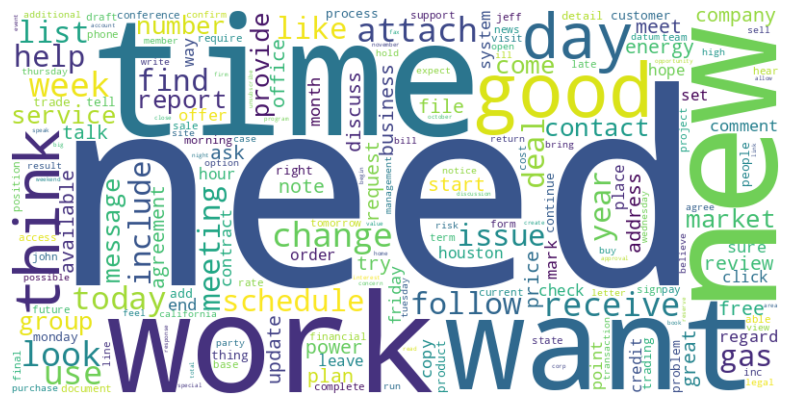

In [17]:
# wordcloud from dfreq 
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Create a word cloud from the frequency dictionary
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dfreq)
wordcloud.to_file("wordcloud.png")
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [20]:
# individual tokens and wordclouds can only tell us so much. let's see phrases
from gensim.models.phrases import Phrases, ENGLISH_CONNECTOR_WORDS

bigram = Phrases(df.tokens, min_count=20, threshold=100, connector_words=ENGLISH_CONNECTOR_WORDS)

trigram = Phrases(bigram[df.tokens], min_count=20, threshold=100)
df["tokens_ph"] = [trigram[bigram[t]] for t in df.tokens]

print(sorted({w for t in df.tokens_ph for w in t if "_" in w})[:50])

['aade_global_completion', 'aadvantage_bonus', 'aapg_annual_meeting', 'aaron_brooks', 'aaron_harris', 'aaron_roffwarg', 'aaron_roffwarg_bracewell_patterson', 'aaron_shea', 'aaron_shea_cle', 'abb_transformer', 'abc_mathrandom_var_random', 'abcnewscom_moment_receive', 'abe_robinson', 'abe_robinson_jersey_village', 'aberdeen_mar_aapg_annual', 'abhay_mehta', 'abn_amro', 'abovenormal_temperature', 'absence_damon_jones', 'absence_fred_beasley', 'abu_dhabi', 'abuse_discretion', 'acapulco_ixtapa', 'accel_partner', 'access_juno_juno', 'accident_coach', 'accompanying_document', 'accompanying_document_attorneyclient_privilege', 'accord_seattle_postintelligencer', 'accounting_irregularity', 'accounting_profession', 'accumulation_inch', 'accuracy_completeness', 'accurate_rely', 'ache_pain', 'achille_tendon', 'acid_rain', 'acquire_osca', 'acquisition_divestiture', 'acrobat_reader', 'action_inaction', 'action_nbsp_faceverdana', 'action_planter_crunch', 'action_reliance', 'active_player_pos', 'active_

I know that aadvantage is probably an american airlines promo. cutting that out of preprocessing. other than this, i think we have some valuable info. Important names of people. Important events. etc.

In [22]:
# Tfidf phrase scoring
from sklearn.feature_extraction.text import TfidfVectorizer

docs = df.tokens_ph.str.join(" ")

# Initialize the TfidfVectorizer
tfidf = TfidfVectorizer(min_df = 5, max_df = 0.5, sublinear_tf = True)
X = tfidf.fit_transform(docs)
vocab = tfidf.get_feature_names_out()
row = X[0].toarray().ravel()



In [23]:
print(sorted(zip(row, vocab), reverse = True)[:10])

[(np.float64(0.4431143511076003), 'bom'), (np.float64(0.38323328123575845), 'trade'), (np.float64(0.3819782256964034), 'feb'), (np.float64(0.28161655938363994), 'howdy'), (np.float64(0.2657289427681169), 'small'), (np.float64(0.26492485776356794), 'erik'), (np.float64(0.2551788495915864), 'volume'), (np.float64(0.22083389783271218), 'mar'), (np.float64(0.21307153347411445), 'lift'), (np.float64(0.17494579331180607), 'dec')]


stock email

In [28]:
# get feature importance through vocab and tfidf matrix (X)

total_tfidf_scores = X.sum(axis = 0).A1
importance_df = pd.DataFrame({"feature": vocab, "importance": total_tfidf_scores})

# sort by importance
importance_df = importance_df.sort_values("importance", ascending = False)

# print the top 10 features
print(importance_df.head(50))

           feature   importance
46632        thank  3364.307167
31423         need  2478.136712
2988        attach  2339.297785
14520        email  2323.121634
29080      meeting  2315.155498
47047         time  2171.014249
31632          new  2153.376994
41872         send  2111.101469
51454         work  2058.224095
46744        think  1963.593460
11439         deal  1909.393839
19340         good  1866.758807
50333         want  1850.811056
7556        change  1833.947154
18589          gas  1833.438442
37543     question  1810.966247
38993       report  1774.180852
27265         look  1727.215712
50639         week  1727.007638
11356          day  1723.716248
871      agreement  1710.219848
47233        today  1673.638205
26948         list  1623.479273
22897  information  1612.863340
49087       update  1570.176057
39070      request  1567.009103
36158        power  1557.515942
41134     schedule  1515.614568
14830       energy  1456.543510
38218      receive  1408.305838
39418   

Since this is tfidf, the scores for each word mean how characteristic and uniquely meaningful a word is to specific documents within your dataset. They highlight CONTEXTUAL weight rather than within the corpus as a whole

### Keyword extraction using YAKE and KeyBERT rather than TF-IDF (old)

In [30]:
import yake
from keybert import KeyBERT
sample = df["body"].iloc[10]
yk = yake.KeywordExtractor(lan="en", n=3, top=8)
print("YAKE:", [k for k, s in yk.extract_keywords(sample)]) # lower score = better

YAKE: ['CenterpieceTM Dear Richard', 'send Thanksgiving gifts', 'Celebration CenterpieceTM Dear', 'Dear Richard', 'send Thanksgiving', 'time to send', 'Thanksgiving', 'Thanksgiving Collection']


In [31]:
kw = KeyBERT(model="all-MiniLM-L6-v2")
print("KeyBERT:", kw.extract_keywords(sample, keyphrase_ngram_range=(1, 3), stop_words="english", use_mmr=True, diversity=0.5, top_n=8))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

KeyBERT: [('access 800 flowers', 0.627), ('thanksgiving gifts autumn', 0.5786), ('flowercornucopia fields europe', 0.4753), ('1800flowers offer valid', 0.4446), ('thanksgiving friends 800', 0.4257), ('europe harvest cheesecakesampler', 0.3797), ('celebration centerpiecetm dear', 0.3399), ('sent rshapiro', 0.1921)]


### Named Entity Recognition

In [33]:
nlp_ner = spacy.load("en_core_web_sm")
ents = []
for doc in nlp_ner.pipe(df["ctfidf_text"], n_process = multiprocessing.cpu_count()-8):
    ents += [(e.text.strip(), e.label_) for e in doc.ents if e.label_ in ["PERSON", "ORG", "GPE", "MONEY"]]

ent_df = pd.DataFrame(ents, columns=["entity", "label"])
print(ent_df.groupby("label")["entity"].value_counts().groupby(level=0).head(10))

label   entity                         
GPE     california                         21234
        houston                            12783
        texas                               8831
        new york                            8080
        us                                  6755
        london                              6365
        washington                          5707
        india                               3674
        san francisco                       3425
        los angeles                         2993
MONEY   billions of dollars                  446
        millions of dollars                  298
        hundreds of millions of dollars      175
        25 billion                           106
        3 cents                              106
        more than 1 billion                  101
        a penny                               97
        9 billion                             88
        45 cents                              71
        276 billion          

In [34]:
ent_df.to_csv("emails_preprocessed_ner.csv", index=False)

### Sentiment Analysis using VADER and Trasnformers

In [13]:
df["ctfidf_text"] = df["ctfidf_text"].fillna("")

In [14]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline

nltk.download("vader_lexicon")
vader = SentimentIntensityAnalyzer()

df["vader"] = df["ctfidf_text"].map(lambda t: vader.polarity_scores(t)["compound"])
roberta = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-basesentiment-latest", truncation=True, max_length=512)

df.loc[df.index[:2000], "roberta"] = [r["label"] for r in roberta(df["ctfidf_text"].head(2000).tolist(), batch_size = 32)]
print(df.groupby(df.date.dt.to_period("M").vader.mean().tail(18)))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/marco/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


OSError: cardiffnlp/twitter-roberta-basesentiment-latest is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`